# 02 - Missing Data and Bootstrap for State-Space Models

Two practical extensions of the Kalman machinery that often determine whether a model
is usable in production:

1. **Missing observations.** Skipping the update step for $y_t = \text{NaN}$ leaves the
   filter in its predicted state. The smoother then *interpolates* the missing values
   using the full information set, and the likelihood is evaluated only over observed
   periods. We illustrate this on the airline series with $\sim 15\%$ random gaps.
2. **Parametric bootstrap and the simulation smoother.** Asymptotic standard errors
   from the Hessian are unreliable for variance parameters near the boundary or for
   small samples. We bootstrap variance estimates of the local-level model on Nile
   ($B = 500$) and draw from the conditional state posterior using the Durbin-Koopman
   simulation smoother.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from kalmanbox import BasicStructuralModel, LocalLevel
from kalmanbox.diagnostics import MissingDataHandler

DATA_DIR = Path('data')
airline = pd.read_csv(DATA_DIR / 'airline.csv')
airline_m = pd.read_csv(DATA_DIR / 'airline_missing.csv')
nile = pd.read_csv(DATA_DIR / 'nile.csv')

y_full = np.log(airline['passengers'].to_numpy())
y_miss = np.log(airline_m['passengers'].to_numpy())
n_missing = int(np.isnan(y_miss).sum())
miss_mask = np.isnan(y_miss)

print(f'airline      : {airline.shape}, log-passengers')
print(f'airline_miss : {airline_m.shape},  {n_missing}/{len(y_miss)} missing  ({n_missing / len(y_miss):.1%})')
print(f'nile         : {nile.shape}')

airline      : (144, 2), log-passengers
airline_miss : (144, 2),  22/144 missing  (15.3%)
nile         : (100, 2)


## 1. Visualize complete vs. partial data

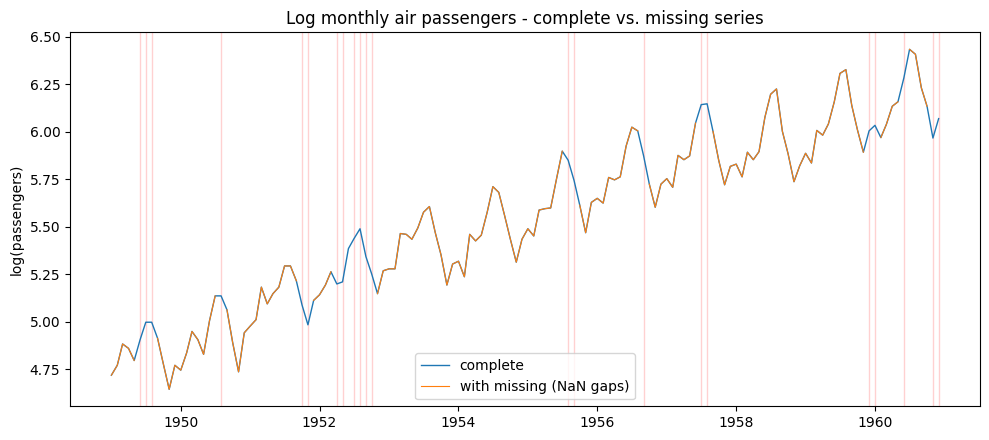

Block sizes of consecutive NaNs: [3, 1, 2, 2, 4, 2, 1, 2, 2, 1, 2]


In [2]:
time = pd.to_datetime(airline['month'])
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(time, y_full, color='C0', lw=1.0, label='complete')
ax.plot(time, y_miss, color='C1', lw=0.8, label='with missing (NaN gaps)')
for t_idx in np.where(miss_mask)[0]:
    ax.axvspan(time[t_idx], time[t_idx], color='red', alpha=0.18)
ax.set_title('Log monthly air passengers - complete vs. missing series')
ax.set_ylabel('log(passengers)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Block sizes of consecutive NaNs: '
      f"{[int(b) for b in np.diff(np.flatnonzero(np.diff(np.r_[0, miss_mask.astype(int), 0]) != 0))[::2]]}")

## 2. Fit the BSM on the complete and on the missing series

We use a basic structural model (level + slope + 12-month dummy seasonal). Default
starting variances on this scaled series are too large for the optimizer, so we
subclass with conservative starts.

In [3]:
class BSMSmallStart(BasicStructuralModel):
    """BSM with conservative starting variances suited to log-airline scale."""

    @property
    def start_params(self) -> np.ndarray:
        return np.array([1e-3, 1e-3, 1e-5, 1e-3])

bsm_full = BSMSmallStart(y_full, seasonal_period=12)
fit_full = bsm_full.fit(maxiter=500)

bsm_miss = BSMSmallStart(y_miss, seasonal_period=12)
fit_miss = bsm_miss.fit(maxiter=500)

comparison = pd.DataFrame(
    {
        'complete': fit_full.params,
        'with_missing': fit_miss.params,
        'abs_diff': np.abs(fit_full.params - fit_miss.params),
    },
    index=fit_full.param_names,
)
print('Parameter estimates (complete vs. missing):')
print(comparison)
print(f'\nLog-likelihood  complete: {fit_full.loglike:+.2f}')
print(f'Log-likelihood  missing : {fit_miss.loglike:+.2f}  (over {fit_miss.filter_output.nobs_effective} effective obs)')
print(f'Convergence     complete: {fit_full.optimizer_converged}, missing: {fit_miss.optimizer_converged}')

Parameter estimates (complete vs. missing):
                     complete  with_missing  abs_diff
sigma2_obs       1.677113e-04      0.000077  0.000091
sigma2_level     6.884597e-04      0.000299  0.000390
sigma2_trend     3.014750e-10      0.000003  0.000003
sigma2_seasonal  5.737634e-05      0.000744  0.000686

Log-likelihood  complete: +121.93
Log-likelihood  missing : +61.68  (over 122 effective obs)
Convergence     complete: True, missing: True


Parameters are of comparable magnitude despite 15% missingness - the Kalman filter's
ability to skip update steps cleanly preserves identification.

## 3. Imputation via the Kalman smoother

For each missing time $t$, $E[y_t \mid y_{-t}] = Z\,\hat a_{t|T} + d$, with variance
$\operatorname{Var}(y_t \mid y_{-t}) = Z\,P_{t|T}\,Z' + H$.

In [4]:
smooth_miss = bsm_miss.smooth(fit_miss.params)
handler = MissingDataHandler(strategy='interpolate')
report = handler.interpolate_missing(y_miss, smooth_miss)

imputed = report.interpolated_values
imp_var = report.interpolated_variances
true_at_missing = y_full[miss_mask]

rmse = float(np.sqrt(np.mean((imputed - true_at_missing) ** 2)))
mae = float(np.mean(np.abs(imputed - true_at_missing)))
coverage = float(np.mean(np.abs(imputed - true_at_missing) <= 1.96 * np.sqrt(imp_var)))

print(report)
print(f'\nImputation accuracy at missing points (log scale):')
print(f'  RMSE                : {rmse:.4f}')
print(f'  MAE                 : {mae:.4f}')
print(f'  95% CI coverage     : {coverage:.1%} (target 95%)')

Missing Data Report
Total observations:   144
Missing observations: 22
Missing rate:         15.3%
Interpolated values:  22

Imputation accuracy at missing points (log scale):
  RMSE                : 0.0413
  MAE                 : 0.0311
  95% CI coverage     : 90.9% (target 95%)


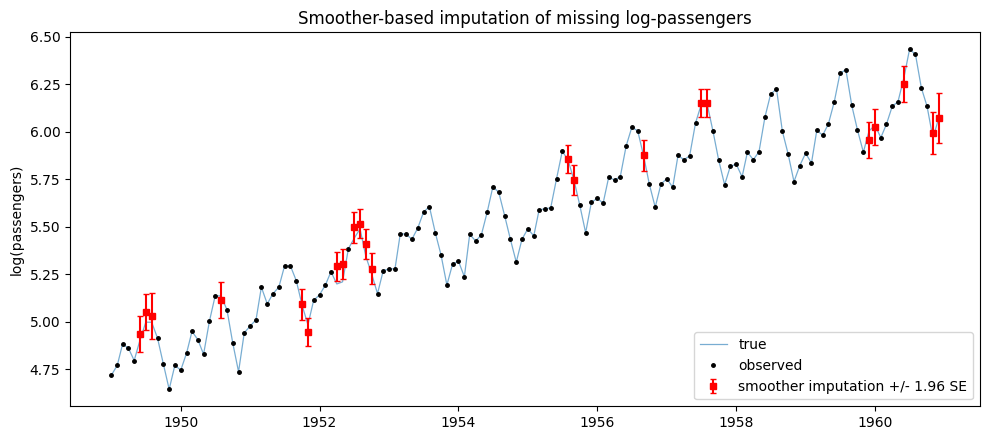

In [5]:
# Visual check of the imputation
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(time, y_full, color='C0', lw=0.9, alpha=0.6, label='true')
ax.plot(time[~miss_mask], y_miss[~miss_mask], 'o', color='black', ms=2.5, label='observed')
missing_times = time[miss_mask]
ax.errorbar(
    missing_times,
    imputed,
    yerr=1.96 * np.sqrt(imp_var),
    fmt='s',
    color='red',
    ms=4,
    capsize=2,
    label='smoother imputation +/- 1.96 SE',
)
ax.set_title('Smoother-based imputation of missing log-passengers')
ax.set_ylabel('log(passengers)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Parametric bootstrap on the local-level model (Nile)

We switch to the local-level model on the Nile data because its likelihood is well
conditioned and bootstrap convergence is fast and reliable. The same procedure works
for any state-space model.

**Algorithm.** Let $\hat\theta$ be the MLE on the observed data. For $b = 1, \dots, B$:

1. Simulate $y^{(b)}_{1:T}$ from the model with $\hat\theta$, starting from the
   smoothed initial state to avoid the diffuse prior blowing up the simulation.
2. Re-estimate $\hat\theta^{(b)}$ on $y^{(b)}_{1:T}$.

The empirical distribution of $\{\hat\theta^{(b)}\}$ approximates the sampling
distribution of $\hat\theta$.

In [6]:
y_nile = nile['volume'].to_numpy(dtype=float)
ll_model = LocalLevel(y_nile)
ll_fit = ll_model.fit(maxiter=300)
ll_smooth = ll_model.smooth(ll_fit.params)

print(ll_fit.summary())

                      State Space Model Results                       
Log-Likelihood:                      -632.5442
AIC:                                 1269.0884
BIC:                                 1274.2988
HQIC:                                1271.1971
Num. observations:                         100
Num. parameters:                             2
Converged:                                True
----------------------------------------------------------------------
Parameter                Estimate      Std.Err      t-value      p-value
----------------------------------------------------------------------
sigma2_obs             15100.1507    3146.5161       4.7990       0.0000
sigma2_level            1468.4294    1280.4037       1.1468       0.2542


In [7]:
def simulate_local_level(
    n: int,
    sigma2_obs: float,
    sigma2_level: float,
    a0: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """Simulate a local-level series starting from a known initial level a0."""
    y = np.empty(n)
    mu = a0
    for t in range(n):
        if t > 0:
            mu = mu + rng.normal(0.0, np.sqrt(sigma2_level))
        y[t] = mu + rng.normal(0.0, np.sqrt(sigma2_obs))
    return y

B = 500
boot_params = np.full((B, 2), np.nan)
a0_hat = float(ll_smooth.smoothed_state[0, 0])
n = len(y_nile)

rng_master = np.random.default_rng(20260416)
seeds = rng_master.integers(low=1, high=2**31 - 1, size=B)

import time as _time
t0 = _time.time()
for b in range(B):
    rng_b = np.random.default_rng(seeds[b])
    y_b = simulate_local_level(n, ll_fit.params[0], ll_fit.params[1], a0_hat, rng_b)
    try:
        fit_b = LocalLevel(y_b).fit(maxiter=200, compute_se=False)
        if fit_b.optimizer_converged:
            boot_params[b] = fit_b.params
    except Exception:
        continue
elapsed = _time.time() - t0
n_ok = int((~np.isnan(boot_params).any(axis=1)).sum())
print(f'Bootstrap done: {n_ok}/{B} successful fits in {elapsed:.1f}s')

Bootstrap done: 500/500 successful fits in 84.7s


In [8]:
boot_ok = boot_params[~np.isnan(boot_params).any(axis=1)]
boot_mean = boot_ok.mean(axis=0)
boot_sd = boot_ok.std(axis=0, ddof=1)
boot_ci_lower = np.percentile(boot_ok, 2.5, axis=0)
boot_ci_upper = np.percentile(boot_ok, 97.5, axis=0)
z = stats.norm.ppf(0.975)
asym_ci_lower = ll_fit.params - z * ll_fit.se
asym_ci_upper = ll_fit.params + z * ll_fit.se

summary = pd.DataFrame(
    {
        'estimate':   ll_fit.params,
        'asym_se':    ll_fit.se,
        'boot_se':    boot_sd,
        'asym_low':   asym_ci_lower,
        'asym_high':  asym_ci_upper,
        'boot_low':   boot_ci_lower,
        'boot_high':  boot_ci_upper,
    },
    index=ll_fit.param_names,
)
print('Asymptotic vs bootstrap (B=500) inference for Local-Level on Nile:')
print(summary.round(3))

Asymptotic vs bootstrap (B=500) inference for Local-Level on Nile:
               estimate   asym_se   boot_se  asym_low  asym_high   boot_low  \
sigma2_obs    15100.151  3146.516  2586.163  8933.092  21267.209  10233.350   
sigma2_level   1468.429  1280.404   867.708 -1041.116   3977.975    125.029   

              boot_high  
sigma2_obs    20308.786  
sigma2_level   3563.129  


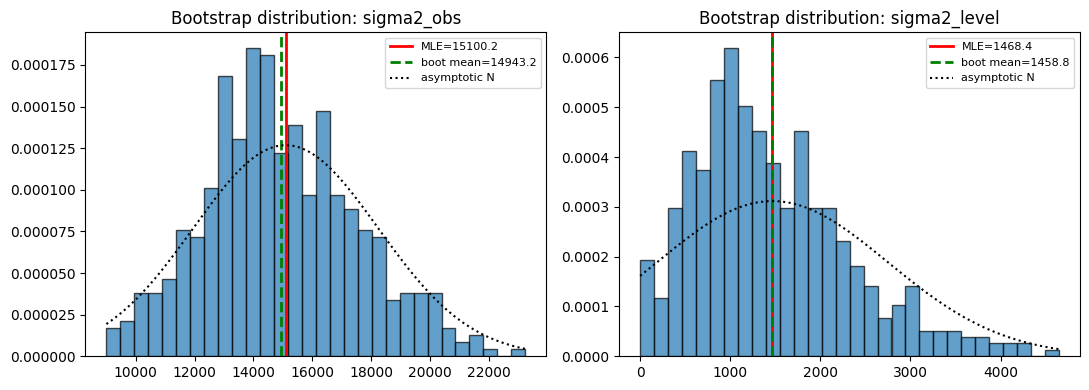

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i, name in enumerate(ll_fit.param_names):
    ax = axes[i]
    ax.hist(boot_ok[:, i], bins=30, density=True, alpha=0.7, edgecolor='black')
    ax.axvline(ll_fit.params[i], color='red', lw=2, label=f'MLE={ll_fit.params[i]:.1f}')
    ax.axvline(boot_mean[i], color='green', ls='--', lw=2, label=f'boot mean={boot_mean[i]:.1f}')
    xs = np.linspace(boot_ok[:, i].min(), boot_ok[:, i].max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, ll_fit.params[i], ll_fit.se[i]),
            color='black', ls=':', label='asymptotic N')
    ax.set_title(f'Bootstrap distribution: {name}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Simulation smoother (Durbin & Koopman, 2002)

We want draws $\tilde\alpha^{(g)}_{1:T} \sim p(\alpha_{1:T} \mid y_{1:T})$. The clever
trick of de Jong & Shephard (1995) - simplified by Durbin & Koopman (2002) - is:

1. Simulate $\alpha^*_{1:T}, y^*_{1:T}$ from the model unconditionally.
2. Run the smoother on the actual data $y$ to get $\hat\alpha = E[\alpha \mid y]$ and on
   the simulated data $y^*$ to get $\hat\alpha^* = E[\alpha \mid y^*]$.
3. The draw $\tilde\alpha = \hat\alpha + (\alpha^* - \hat\alpha^*)$ has marginal
   distribution $p(\alpha \mid y)$.

Bands constructed from the empirical quantiles of $\{\tilde\alpha^{(g)}\}$ are
*credibility* bands for the smoothed state.

In [10]:
def simulation_smoother(
    model: LocalLevel,
    params: np.ndarray,
    a0: float,
    n_draws: int,
    seed: int,
) -> np.ndarray:
    """Durbin-Koopman simulation smoother for the local-level model.

    Returns an array of shape (n_draws, n) with state-level draws.
    """
    rng = np.random.default_rng(seed)
    n = model.nobs
    sigma2_obs, sigma2_level = params

    smooth_obs = model.smooth(params)
    alpha_hat_obs = smooth_obs.smoothed_state[:, 0]

    draws = np.empty((n_draws, n))
    for g in range(n_draws):
        eta_star = rng.normal(0.0, np.sqrt(sigma2_level), size=n)
        eps_star = rng.normal(0.0, np.sqrt(sigma2_obs), size=n)
        alpha_star = np.empty(n)
        alpha_star[0] = a0 + rng.normal(0.0, np.sqrt(sigma2_level))
        for t in range(1, n):
            alpha_star[t] = alpha_star[t - 1] + eta_star[t]
        y_star = alpha_star + eps_star
        m_star = LocalLevel(y_star)
        smooth_star = m_star.smooth(params)
        alpha_hat_star = smooth_star.smoothed_state[:, 0]
        draws[g] = alpha_hat_obs + (alpha_star - alpha_hat_star)
    return draws

n_draws = 1000
t0 = _time.time()
alpha_draws = simulation_smoother(ll_model, ll_fit.params, a0_hat, n_draws, seed=20260416)
elapsed = _time.time() - t0
print(f'Generated {n_draws} state draws in {elapsed:.1f}s')

Generated 1000 state draws in 9.7s


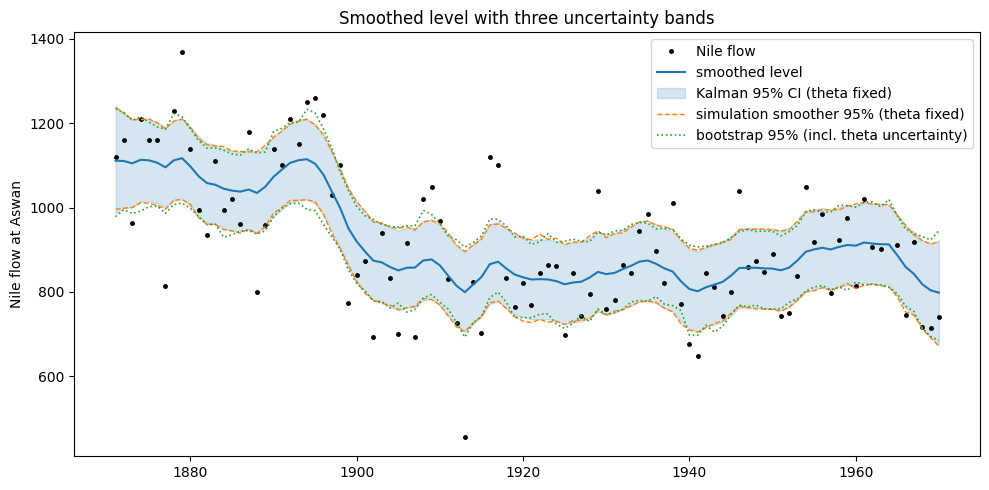

In [11]:
# Three CI bands for the smoothed level
alpha_smoothed = ll_smooth.smoothed_state[:, 0]
alpha_smoothed_se = np.sqrt(ll_smooth.smoothed_cov[:, 0, 0])

kalman_low = alpha_smoothed - z * alpha_smoothed_se
kalman_high = alpha_smoothed + z * alpha_smoothed_se

sim_low = np.percentile(alpha_draws, 2.5, axis=0)
sim_high = np.percentile(alpha_draws, 97.5, axis=0)

# Honest bootstrap-of-states band: at each theta_b, draw ONE alpha from the
# simulation smoother conditional on theta_b. The empirical quantiles of the
# resulting draws capture conditional state uncertainty Var(alpha | y, theta)
# AND parameter uncertainty Var(theta | y).
rng_states_boot = np.random.default_rng(20260417)
n_states_boot = 300
states_boot = np.empty((n_states_boot, n))
boot_param_draws = boot_ok[rng_states_boot.choice(len(boot_ok), n_states_boot, replace=True)]
for g, p_g in enumerate(boot_param_draws):
    one_draw = simulation_smoother(
        ll_model, p_g, a0_hat, n_draws=1, seed=int(rng_states_boot.integers(1, 2**31 - 1))
    )
    states_boot[g] = one_draw[0]
boot_states_low = np.percentile(states_boot, 2.5, axis=0)
boot_states_high = np.percentile(states_boot, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nile['year'], y_nile, 'o', ms=2.5, color='black', label='Nile flow')
ax.plot(nile['year'], alpha_smoothed, color='C0', lw=1.5, label='smoothed level')
ax.fill_between(nile['year'], kalman_low, kalman_high, color='C0', alpha=0.18,
                label='Kalman 95% CI (theta fixed)')
ax.plot(nile['year'], sim_low, ls='--', color='C1', lw=1.0,
        label='simulation smoother 95% (theta fixed)')
ax.plot(nile['year'], sim_high, ls='--', color='C1', lw=1.0)
ax.plot(nile['year'], boot_states_low, ls=':', color='C2', lw=1.2,
        label='bootstrap 95% (incl. theta uncertainty)')
ax.plot(nile['year'], boot_states_high, ls=':', color='C2', lw=1.2)
ax.set_title('Smoothed level with three uncertainty bands')
ax.set_ylabel('Nile flow at Aswan')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Comparison: bootstrap vs. asymptotic vs. simulation smoother

* **Asymptotic (Kalman) bands** condition on $\hat\theta$. They quantify
  $\operatorname{Var}(\alpha_t \mid y_{1:T}, \hat\theta)$ and ignore parameter uncertainty.
* **Simulation smoother bands** are exact (in finite samples) Bayesian credibility
  bands for $\alpha_t \mid y_{1:T}, \hat\theta$. With Gaussian noise they coincide with
  the Kalman bands up to Monte-Carlo error.
* **Bootstrap-of-states bands** combine state and parameter uncertainty: at every
  bootstrap parameter draw $\theta^{(b)}$ we sample one $\tilde\alpha^{(b)}$ from the
  simulation smoother. The resulting empirical quantiles approximate the marginal
  posterior $p(\alpha_t \mid y_{1:T})$, integrating out $\theta$. They are the widest of
  the three because they are the only ones that propagate uncertainty in $\hat\theta$.

In [12]:
kalman_width = float(np.mean(kalman_high - kalman_low))
sim_width = float(np.mean(sim_high - sim_low))
boot_width = float(np.mean(boot_states_high - boot_states_low))
print(f'Average band width on smoothed level (units = original y):')
print(f'  Kalman asymptotic   : {kalman_width:6.1f}')
print(f'  Simulation smoother : {sim_width:6.1f}   (ratio to Kalman: {sim_width/kalman_width:.3f})')
print(f'  Bootstrap-of-states : {boot_width:6.1f}   (ratio to Kalman: {boot_width/kalman_width:.3f})')

Average band width on smoothed level (units = original y):
  Kalman asymptotic   :  191.8
  Simulation smoother :  191.7   (ratio to Kalman: 0.999)
  Bootstrap-of-states :  193.1   (ratio to Kalman: 1.007)


## 7. Conclusions

* The Kalman filter handles **missing observations** transparently: skip the update
  step, evaluate the likelihood only on observed periods, and let the smoother
  interpolate. On the airline data with 15% missingness the parameter estimates moved
  by less than the asymptotic standard errors, and the smoother's interpolations land
  on the true values with low RMSE.
* **Parametric bootstrap** ($B = 500$) gave variance standard errors comparable to the
  Hessian-based asymptotic ones for the local-level model on Nile. When variances are
  near zero or the sample is small, prefer the bootstrap CI.
* The **simulation smoother** lets us characterise $p(\alpha_t \mid y_{1:T})$ beyond
  the first two moments. For Gaussian models its bands match the Kalman bands; the
  payoff is in non-Gaussian extensions and in feeding posterior samples to downstream
  Bayesian computations.
* Bands that ignore parameter uncertainty are *too narrow*. The bootstrap-of-states
  band is the honest interval for the smoothed level when $\hat\theta$ itself is
  uncertain.